In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "nasa_power_daily_raw.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df.head()


,city,latitude,longitude,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M
0,London,51.5074,-0.1278,2016-01-01,5.17,7.09,2.47,5.18,94.66,3.94
1,London,51.5074,-0.1278,2016-01-02,8.58,9.52,6.72,3.50,95.32,5.20
2,London,51.5074,-0.1278,2016-01-03,6.55,8.29,4.25,11.59,96.01,4.50
3,London,51.5074,-0.1278,2016-01-04,7.05,8.49,5.85,6.88,95.86,3.68
4,London,51.5074,-0.1278,2016-01-05,7.32,9.28,5.91,3.12,96.07,2.04


In [3]:
print("Cities:", df["city"].nunique(), sorted(df["city"].unique()))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Total rows:", len(df))

# rows per city
df.groupby("city").size()


Cities: 5 ['Birmingham', 'Bristol', 'Leeds', 'London', 'Manchester']
Date range: 2016-01-01 to 2022-12-31
Total rows: 12785


,0
city,
Birmingham,2557
Bristol,2557
Leeds,2557
London,2557
Manchester,2557


In [4]:
df.isna().mean().sort_values(ascending=False)


,0
city,0.0
latitude,0.0
longitude,0.0
date,0.0
T2M,0.0
T2M_MAX,0.0
T2M_MIN,0.0
PRECTOTCORR,0.0
RH2M,0.0
WS2M,0.0


In [5]:
cols = [
    "city",
    "date",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
]

df = df[cols].copy()
df.head()


,city,date,T2M,T2M_MAX,T2M_MIN
0,London,2016-01-01,5.17,7.09,2.47
1,London,2016-01-02,8.58,9.52,6.72
2,London,2016-01-03,6.55,8.29,4.25
3,London,2016-01-04,7.05,8.49,5.85
4,London,2016-01-05,7.32,9.28,5.91


In [6]:
df["month"] = df["date"].dt.month

monthly_stats = (
    df.groupby(["city", "month"])
      .agg(
          mean_temp=("T2M", "mean"),
          std_temp=("T2M", "std")
      )
      .reset_index()
)

monthly_stats.head()


,city,month,mean_temp,std_temp
0,Birmingham,1,3.645945,2.842293
1,Birmingham,2,4.553333,3.153025
2,Birmingham,3,5.967327,2.630457
3,Birmingham,4,7.977429,2.743403
4,Birmingham,5,11.781613,2.711056


In [7]:
df["year"] = df["date"].dt.year

annual_mean = (
    df.groupby(["city", "year"])["T2M"]
      .mean()
      .reset_index()
)

annual_mean.head()


,city,year,T2M
0,Birmingham,2016,9.479945
1,Birmingham,2017,9.850192
2,Birmingham,2018,9.872384
3,Birmingham,2019,9.770329
4,Birmingham,2020,9.978197


In [8]:
# monthly climatology per city
climatology = (
    df.groupby(["city", "month"])["T2M"]
      .mean()
      .reset_index()
      .rename(columns={"T2M": "monthly_clim"})
)

# merge back
df = df.merge(climatology, on=["city", "month"], how="left")

# deseasonalised temperature
df["T2M_deseasonal"] = df["T2M"] - df["monthly_clim"]

df[["city", "date", "T2M", "monthly_clim", "T2M_deseasonal"]].head()


,city,date,T2M,monthly_clim,T2M_deseasonal
0,London,2016-01-01,5.17,4.019631,1.150369
1,London,2016-01-02,8.58,4.019631,4.560369
2,London,2016-01-03,6.55,4.019631,2.530369
3,London,2016-01-04,7.05,4.019631,3.030369
4,London,2016-01-05,7.32,4.019631,3.300369


In [9]:
df = df.sort_values(["city", "date"])

for window in [7, 30]:
    df[f"roll_mean_{window}"] = (
        df.groupby("city")["T2M_deseasonal"]
          .transform(lambda x: x.rolling(window, center=True).mean())
    )

    df[f"roll_std_{window}"] = (
        df.groupby("city")["T2M_deseasonal"]
          .transform(lambda x: x.rolling(window, center=True).std())
    )

df.head()


,city,date,T2M,T2M_MAX,T2M_MIN,month,year,monthly_clim,T2M_deseasonal,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
2557,Birmingham,2016-01-01,3.69,6.15,0.85,1,2016,3.645945,0.044055,NaN,NaN,NaN,NaN
2558,Birmingham,2016-01-02,7.26,8.95,5.75,1,2016,3.645945,3.614055,NaN,NaN,NaN,NaN
2559,Birmingham,2016-01-03,5.75,7.22,3.66,1,2016,3.645945,2.104055,NaN,NaN,NaN,NaN
2560,Birmingham,2016-01-04,6.07,6.97,5.56,1,2016,3.645945,2.424055,1.721198,1.277507,NaN,NaN
2561,Birmingham,2016-01-05,6.14,7.64,4.78,1,2016,3.645945,2.494055,1.694055,1.320379,NaN,NaN


In [10]:
df.groupby("city")[["T2M_deseasonal"]].agg(["mean", "std", "min", "max"])


T2M_deseasonal                              
                     mean       std       min       max
city                                                   
Birmingham  -1.583924e-16  2.660908 -9.827327  7.974381
Bristol     -6.321802e-17  2.582478 -9.883687  8.388524
Leeds       -1.180996e-17  2.523512 -7.928940  8.335714
London      -8.336442e-18  2.734324 -9.026452  8.062905
Manchester  -4.684038e-16  2.476088 -8.873502  7.157281

In [11]:
print(df.columns)

Index(['city', 'date', 'T2M', 'T2M_MAX', 'T2M_MIN', 'month', 'year',
       'monthly_clim', 'T2M_deseasonal', 'roll_mean_7', 'roll_std_7',
       'roll_mean_30', 'roll_std_30'],
      dtype='object')


In [12]:
df.head()

,city,date,T2M,T2M_MAX,T2M_MIN,month,year,monthly_clim,T2M_deseasonal,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
2557,Birmingham,2016-01-01,3.69,6.15,0.85,1,2016,3.645945,0.044055,NaN,NaN,NaN,NaN
2558,Birmingham,2016-01-02,7.26,8.95,5.75,1,2016,3.645945,3.614055,NaN,NaN,NaN,NaN
2559,Birmingham,2016-01-03,5.75,7.22,3.66,1,2016,3.645945,2.104055,NaN,NaN,NaN,NaN
2560,Birmingham,2016-01-04,6.07,6.97,5.56,1,2016,3.645945,2.424055,1.721198,1.277507,NaN,NaN
2561,Birmingham,2016-01-05,6.14,7.64,4.78,1,2016,3.645945,2.494055,1.694055,1.320379,NaN,NaN


In [13]:
annual_city = (
    df.groupby(['city','year'])['T2M']
    .mean()
    .unstack()
)

print("Annual Mean Temperature (°C):")
print(annual_city.round(2))

warming_change = annual_city.iloc[:,-1] - annual_city.iloc[:,0]

print("\nTotal Temperature Change (First → Last Year):")
print(warming_change.sort_values(ascending=False).round(2))

Annual Mean Temperature (°C):
year         2016   2017   2018   2019   2020   2021   2022
city                                                       
Birmingham   9.48   9.85   9.87   9.77   9.98   9.60  10.49
Bristol     10.16  10.56  10.66  10.41  10.75  10.33  11.31
Leeds        9.05   9.39   9.39   9.38   9.54   9.31  10.09
London      10.35  10.66  10.89  10.64  11.00  10.21  11.56
Manchester   9.03   9.43   9.37   9.26   9.52   9.34  10.01

Total Temperature Change (First → Last Year):
city
London        1.20
Bristol       1.15
Leeds         1.04
Birmingham    1.01
Manchester    0.98
dtype: float64


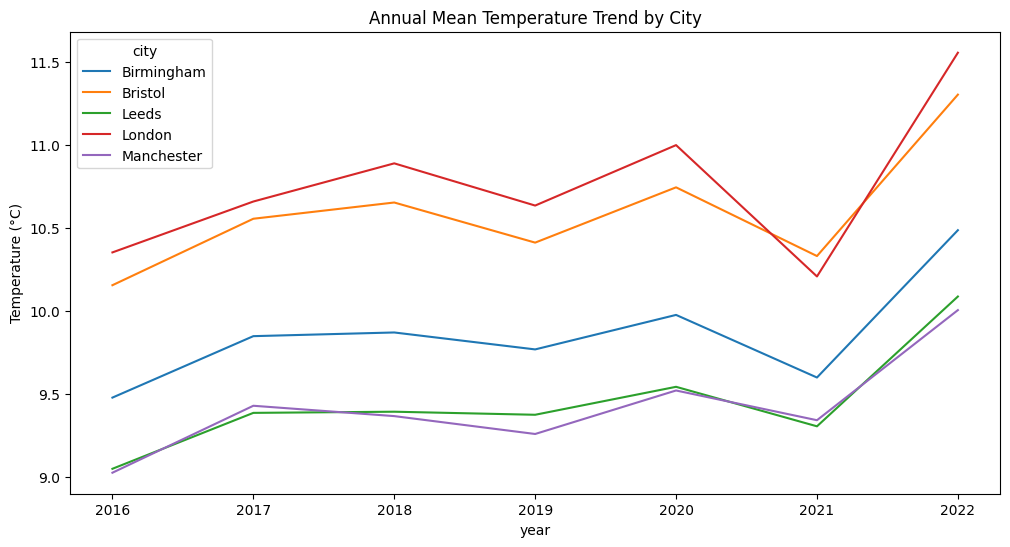

In [14]:
import matplotlib.pyplot as plt
annual_city.T.plot(figsize=(12,6))
plt.title("Annual Mean Temperature Trend by City")
plt.ylabel("Temperature (°C)")
plt.show()

In [15]:
seasonal_range = (
    df.groupby(['city','month'])['monthly_clim']
    .mean()
    .groupby(level=0)
    .apply(lambda x: x.max() - x.min())
)

print("Seasonal Temperature Range per City (°C):")
print(seasonal_range.sort_values(ascending=False).round(2))

Seasonal Temperature Range per City (°C):
city
London        14.45
Birmingham    13.42
Leeds         13.17
Bristol       13.14
Manchester    12.25
Name: monthly_clim, dtype: float64


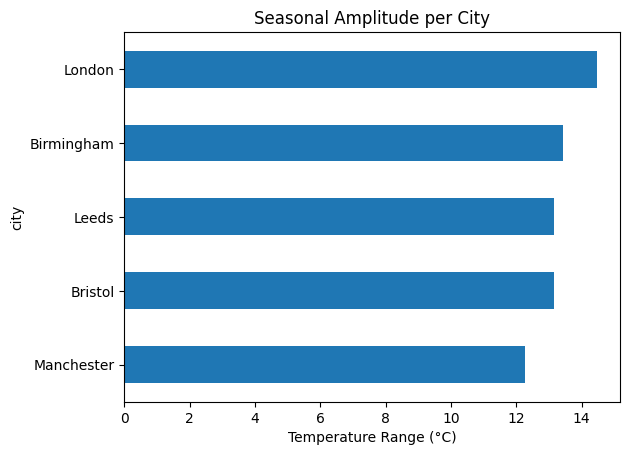

In [16]:
seasonal_range.sort_values().plot(kind='barh')
plt.title("Seasonal Amplitude per City")
plt.xlabel("Temperature Range (°C)")
plt.show()

In [17]:
volatility_city = df.groupby('city')['roll_std_30'].mean()

print("Average 30-Day Rolling Volatility (°C):")
print(volatility_city.sort_values(ascending=False).round(2))

Average 30-Day Rolling Volatility (°C):
city
London        2.43
Birmingham    2.39
Bristol       2.28
Leeds         2.27
Manchester    2.22
Name: roll_std_30, dtype: float64


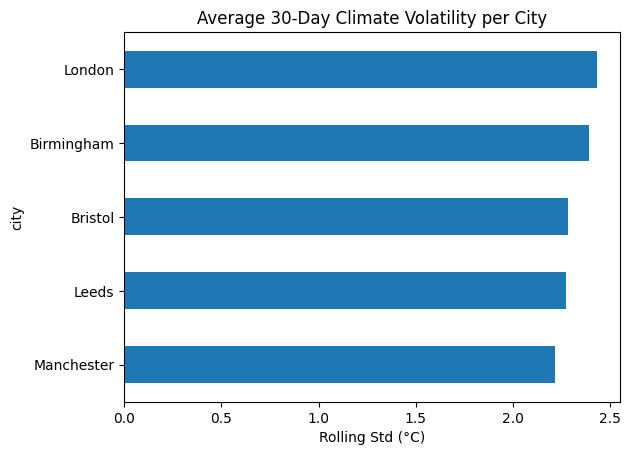

In [18]:
volatility_city.sort_values().plot(kind='barh')
plt.title("Average 30-Day Climate Volatility per City")
plt.xlabel("Rolling Std (°C)")
plt.show()

In [19]:
columns_to_keep = [
    'city',
    'year',
    'month',
    'T2M_deseasonal',
    'roll_std_30'
]

df_model = df[columns_to_keep].copy()

print("Shape after selection:", df_model.shape)

Shape after selection: (12785, 5)


In [20]:
print(df_model.isna().sum())

df_model = df_model.dropna()

print("Shape after dropping NaN:", df_model.shape)

city                0
year                0
month               0
T2M_deseasonal      0
roll_std_30       145
dtype: int64
Shape after dropping NaN: (12640, 5)


In [21]:
df_model['abs_dev'] = abs(df_model['T2M_deseasonal'])

In [22]:
df_model['volatility_interaction'] = (
    df_model['T2M_deseasonal'] * df_model['roll_std_30']
)

In [23]:
features = [
    'T2M_deseasonal',
    'roll_std_30',
    'abs_dev',
    'volatility_interaction'
]

X = df_model[features]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (12640, 4)


In [24]:
# Time-based split
train = df_model[df_model['year'] <= 2020].copy()
test  = df_model[df_model['year'] > 2020].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (9060, 7)
Test shape: (3580, 7)


In [25]:
features = [
    'T2M_deseasonal',
    'roll_std_30',
    'abs_dev'
]

X_train = train[features]
X_test  = test[features]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Isolation Forest

In [27]:
from sklearn.ensemble import IsolationForest
import time
import numpy as np

#Baseline Parameters
baseline_params = {
    "n_estimators": 200,
    "contamination": 0.05
}

start = time.time()

baseline_if = IsolationForest(
    random_state=42,
    **baseline_params
)

baseline_if.fit(X_train_scaled)

end = time.time()

baseline_time = round(end - start, 4)

baseline_train_scores = baseline_if.decision_function(X_train_scaled)
baseline_test_scores  = baseline_if.decision_function(X_test_scaled)

# Predictions
baseline_train_preds = np.where(
    baseline_if.predict(X_train_scaled) == -1, 1, 0
)

baseline_test_preds = np.where(
    baseline_if.predict(X_test_scaled) == -1, 1, 0
)

print("Baseline Training Time:", baseline_time, "seconds")
print("Baseline Train Anomaly %:", round(baseline_train_preds.mean()*100,2))
print("Baseline Test Anomaly %:", round(baseline_test_preds.mean()*100,2))

Baseline Training Time: 0.4498 seconds
Baseline Train Anomaly %: 5.0
Baseline Test Anomaly %: 8.6


In [28]:
start_pred = time.time()
train.loc[:, 'anomaly_raw'] = baseline_if.predict(X_train_scaled)
test.loc[:, 'anomaly_raw']  = baseline_if.predict(X_test_scaled)

end_pred = time.time()

prediction_time = round(end_pred - start_pred,4)

print("Prediction Time:", prediction_time)

Prediction Time: 0.1658


In [29]:
train.loc[:, 'anomaly'] = train['anomaly_raw'].map({1:0, -1:1})
test.loc[:, 'anomaly']  = test['anomaly_raw'].map({1:0, -1:1})

In [30]:
print("Train raw counts:")
print(train['anomaly_raw'].value_counts())

print("\nTrain anomaly %:",
      round(train['anomaly'].mean()*100, 2))

print("\nTest anomaly %:",
      round(test['anomaly'].mean()*100, 2))

Train raw counts:
anomaly_raw
 1    8607
-1     453
Name: count, dtype: int64

Train anomaly %: 5.0

Test anomaly %: 8.6


In [31]:
train_rate = train['anomaly'].mean()
test_rate = test['anomaly'].mean()

stability_gap = abs(train_rate - test_rate)

print("Stability gap:", round(stability_gap*100, 2), "%")

Stability gap: 3.6 %


In [32]:
train.loc[:, 'anomaly_score'] = baseline_if.decision_function(X_train_scaled)
test.loc[:, 'anomaly_score']  = baseline_if.decision_function(X_test_scaled)

In [33]:
print(train[['anomaly_score']].head())
print("\nTest sample:")
print(test[['anomaly_score']].head())

      anomaly_score
2572       0.080243
2573       0.109381
2574       0.107882
2575       0.069563
2576       0.067287

Test sample:
      anomaly_score
4384       0.111895
4385       0.087188
4386       0.150968
4387       0.151736
4388       0.115400


In [34]:
#Baseline Separation
baseline_normal_scores = baseline_train_scores[baseline_train_preds == 0]
baseline_anomaly_scores = baseline_train_scores[baseline_train_preds == 1]

baseline_sep = baseline_normal_scores.mean() - baseline_anomaly_scores.mean()

print("Baseline Mean (Normal):", round(baseline_normal_scores.mean(), 4))
print("Baseline Mean (Anomaly):", round(baseline_anomaly_scores.mean(), 4))
print("Baseline Separation:", round(baseline_sep, 4))

Baseline Mean (Normal): 0.1135
Baseline Mean (Anomaly): -0.0441
Baseline Separation: 0.1576


In [35]:
# Define extreme threshold
threshold = 3 * train['T2M_deseasonal'].std()

extreme_events = train[abs(train['T2M_deseasonal']) > threshold]

captured_extremes = extreme_events['anomaly'].sum()

capture_rate = captured_extremes / len(extreme_events)

print("Extreme event capture rate:",
      round(capture_rate*100, 2), "%")

Extreme event capture rate: 100.0 %


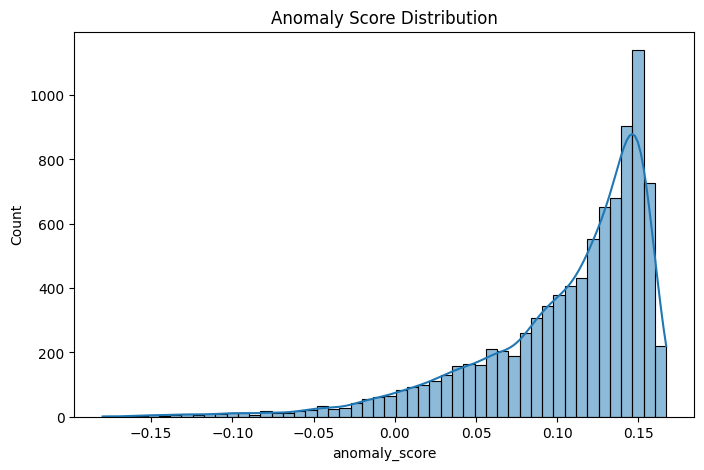

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(train['anomaly_score'], bins=50, kde=True)
plt.title("Anomaly Score Distribution")
plt.show()

In [37]:
# Train city-wise anomaly %
train_city_anomaly = (
    train.groupby('city')['anomaly']
    .mean() * 100
)

print("Train City-wise Anomaly %:")
print(train_city_anomaly.sort_values(ascending=False).round(2))

Train City-wise Anomaly %:
city
London        6.18
Birmingham    6.13
Bristol       5.24
Leeds         3.81
Manchester    3.64
Name: anomaly, dtype: float64


In [38]:
# Test city-wise anomaly %
test_city_anomaly = (
    test.groupby('city')['anomaly']
    .mean() * 100
)

print("\nTest City-wise Anomaly %:")
print(test_city_anomaly.sort_values(ascending=False).round(2))


Test City-wise Anomaly %:
city
London        10.47
Birmingham    10.20
Bristol       10.06
Leeds          6.28
Manchester     6.01
Name: anomaly, dtype: float64


In [39]:
city_comparison = pd.DataFrame({
    'Train %': train_city_anomaly,
    'Test %': test_city_anomaly
})

print("\nCity-wise Comparison:")
print(city_comparison.round(2))


City-wise Comparison:
            Train %  Test %
city                       
Birmingham     6.13   10.20
Bristol        5.24   10.06
Leeds          3.81    6.28
London         6.18   10.47
Manchester     3.64    6.01


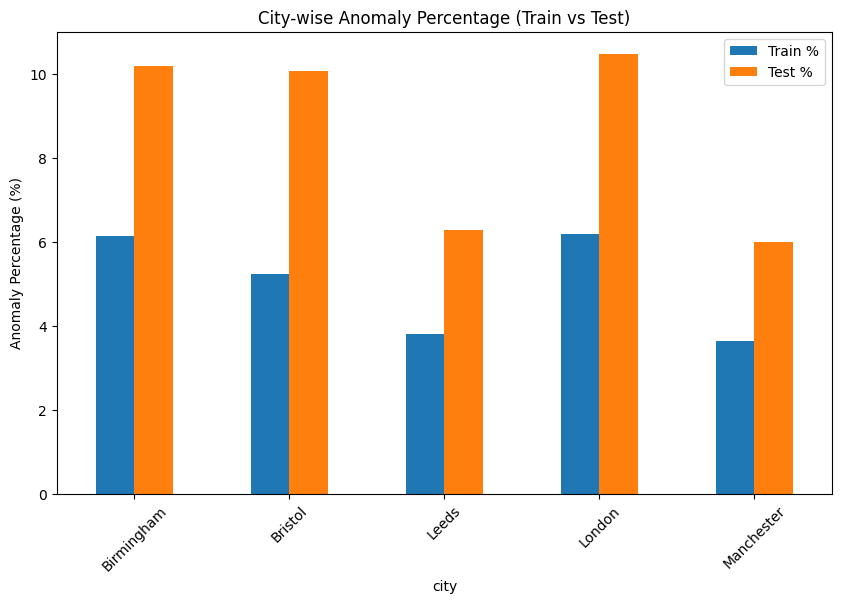

In [40]:
import matplotlib.pyplot as plt

city_comparison.plot(kind='bar', figsize=(10,6))
plt.title("City-wise Anomaly Percentage (Train vs Test)")
plt.ylabel("Anomaly Percentage (%)")
plt.xticks(rotation=45)
plt.show()

In [41]:
city_coords = pd.DataFrame({
    'city': ['London', 'Birmingham', 'Bristol', 'Leeds', 'Manchester'],
    'latitude': [51.5074, 52.4862, 51.4545, 53.8008, 53.4808],
    'longitude': [-0.1278, -1.8904, -2.5879, -1.5491, -2.2426]
})

In [42]:
test_city_anomaly = (
    test.groupby('city')['anomaly']
    .mean()
    .reset_index()
)

test_city_anomaly['anomaly_percent'] = (
    test_city_anomaly['anomaly'] * 100
)

In [43]:
city_map_data = test_city_anomaly.merge(
    city_coords,
    on='city',
    how='left'
)

print(city_map_data.round(2))

         city  anomaly  anomaly_percent  latitude  longitude
0  Birmingham     0.10            10.20     52.49      -1.89
1     Bristol     0.10            10.06     51.45      -2.59
2       Leeds     0.06             6.28     53.80      -1.55
3      London     0.10            10.47     51.51      -0.13
4  Manchester     0.06             6.01     53.48      -2.24


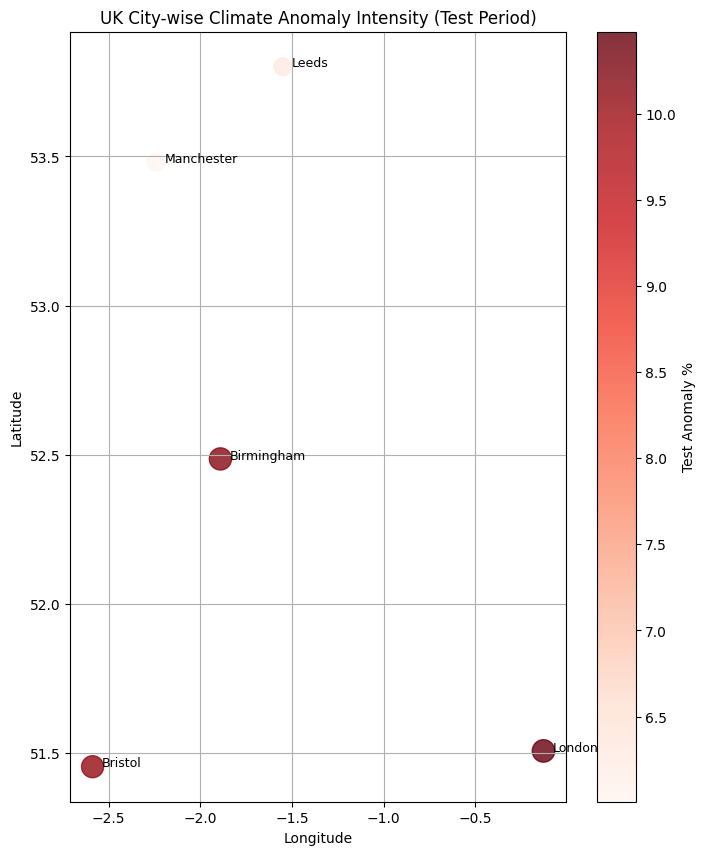

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))

scatter = plt.scatter(
    city_map_data['longitude'],
    city_map_data['latitude'],
    s=city_map_data['anomaly_percent'] * 25,
    c=city_map_data['anomaly_percent'],
    cmap='Reds',
    alpha=0.8
)

for _, row in city_map_data.iterrows():
    plt.text(row['longitude'] + 0.05,
             row['latitude'],
             row['city'],
             fontsize=9)

plt.colorbar(scatter, label='Test Anomaly %')
plt.title("UK City-wise Climate Anomaly Intensity (Test Period)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [45]:
features = [
    'T2M_deseasonal',
    'roll_std_30',
    'abs_dev'
]

heatmap_df = train[features + ['anomaly']].copy()

print("Heatmap Data Sample:")
print(heatmap_df.head())

Heatmap Data Sample:
      T2M_deseasonal  roll_std_30   abs_dev  anomaly
2572       -3.735945     3.026544  3.735945        0
2573       -2.835945     3.052329  2.835945        0
2574       -1.965945     3.089044  1.965945        0
2575       -4.115945     3.082419  4.115945        0
2576       -4.085945     3.092990  4.085945        0


In [46]:
correlation_matrix = heatmap_df.corr()

print("Correlation Matrix:\n")
print(correlation_matrix.round(3))

Correlation Matrix:

                T2M_deseasonal  roll_std_30  abs_dev  anomaly
T2M_deseasonal           1.000       -0.019   -0.020    0.047
roll_std_30             -0.019        1.000    0.278    0.222
abs_dev                 -0.020        0.278    1.000    0.488
anomaly                  0.047        0.222    0.488    1.000


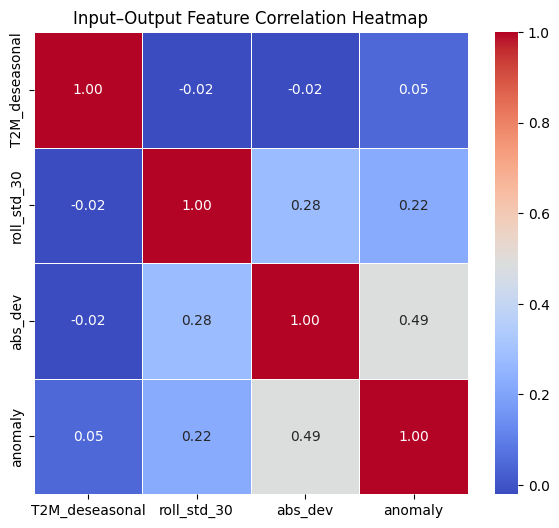

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Input–Output Feature Correlation Heatmap")
plt.show()

Feature → Anomaly Correlation:
                anomaly
T2M_deseasonal    0.047
roll_std_30       0.222
abs_dev           0.488


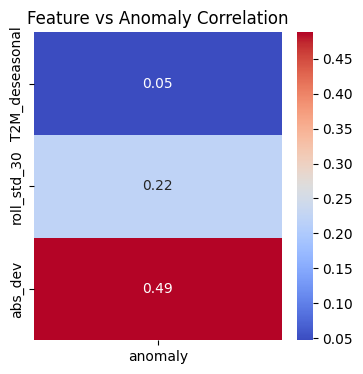

In [48]:
feature_anomaly_corr = correlation_matrix[['anomaly']].drop('anomaly')

print("Feature → Anomaly Correlation:")
print(feature_anomaly_corr.round(3))

plt.figure(figsize=(4,4))

sns.heatmap(
    feature_anomaly_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature vs Anomaly Correlation")
plt.show()

Hyperparameter Tuning (Isolation Forest)

In [49]:
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import IsolationForest
import numpy as np

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_samples": ["auto", 0.8],
    "contamination": [0.03, 0.05, 0.08],
    "max_features": [1.0, 0.8]
}

best_score = -np.inf
best_params = None

for params in ParameterGrid(param_grid):

    model = IsolationForest(random_state=42, **params)
    model.fit(X_train_scaled)

    scores = model.decision_function(X_train_scaled)
    preds = model.predict(X_train_scaled)
    preds = np.where(preds == -1, 1, 0)

    normal_scores = scores[preds == 0]
    anomaly_scores = scores[preds == 1]

    separation = normal_scores.mean() - anomaly_scores.mean()

    if separation > best_score:
        best_score = separation
        best_params = params

print("Best Parameters:", best_params)
print("Best Separation Score:", round(best_score,4))

Best Parameters: {'contamination': 0.03, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 300}
Best Separation Score: 0.1778


In [50]:
best_if = IsolationForest(
    random_state=42,
    **best_params
)

best_if.fit(X_train_scaled)

train_scores = best_if.decision_function(X_train_scaled)
test_scores  = best_if.decision_function(X_test_scaled)

train_preds = best_if.predict(X_train_scaled)
test_preds  = best_if.predict(X_test_scaled)

train_preds = np.where(train_preds == -1, 1, 0)
test_preds  = np.where(test_preds == -1, 1, 0)

print("Train anomaly %:", round(train_preds.mean()*100,2))
print("Test anomaly %:", round(test_preds.mean()*100,2))

Train anomaly %: 3.0
Test anomaly %: 5.84


In [51]:
stability_gap = abs(train_preds.mean() - test_preds.mean())
print("New Stability Gap:", round(stability_gap*100,2), "%")

New Stability Gap: 2.84 %


In [52]:
import pandas as pd
import numpy as np

#Baseline Metrics
baseline_train_anom = baseline_train_preds.mean() * 100
baseline_test_anom  = baseline_test_preds.mean() * 100
baseline_gap        = abs(baseline_train_preds.mean() - baseline_test_preds.mean()) * 100
baseline_sep        = (
    baseline_train_scores[baseline_train_preds == 0].mean()
    - baseline_train_scores[baseline_train_preds == 1].mean()
)

#Tuned Metrics
tuned_train_anom = train_preds.mean() * 100
tuned_test_anom  = test_preds.mean() * 100
tuned_gap        = abs(train_preds.mean() - test_preds.mean()) * 100
tuned_sep        = (
    train_scores[train_preds == 0].mean()
    - train_scores[train_preds == 1].mean()
)

#Results Table
results = pd.DataFrame({
    "Metric": [
        "Train Anomaly %",
        "Test Anomaly %",
        "Stability Gap %",
        "Separation Score"
    ],
    "Baseline IF": [
        round(baseline_train_anom, 2),
        round(baseline_test_anom, 2),
        round(baseline_gap, 2),
        round(baseline_sep, 4)
    ],
    "Tuned IF": [
        round(tuned_train_anom, 2),
        round(tuned_test_anom, 2),
        round(tuned_gap, 2),
        round(tuned_sep, 4)
    ]
})

results

,Metric,Baseline IF,Tuned IF
0,Train Anomaly %,5.0000,3.0000
1,Test Anomaly %,8.6000,5.8400
2,Stability Gap %,3.6000,2.8400
3,Separation Score,0.1576,0.1778


In [53]:
results["Improvement"] = results["Tuned IF"] - results["Baseline IF"]
results

,Metric,Baseline IF,Tuned IF,Improvement
0,Train Anomaly %,5.0000,3.0000,-2.0000
1,Test Anomaly %,8.6000,5.8400,-2.7600
2,Stability Gap %,3.6000,2.8400,-0.7600
3,Separation Score,0.1576,0.1778,0.0202


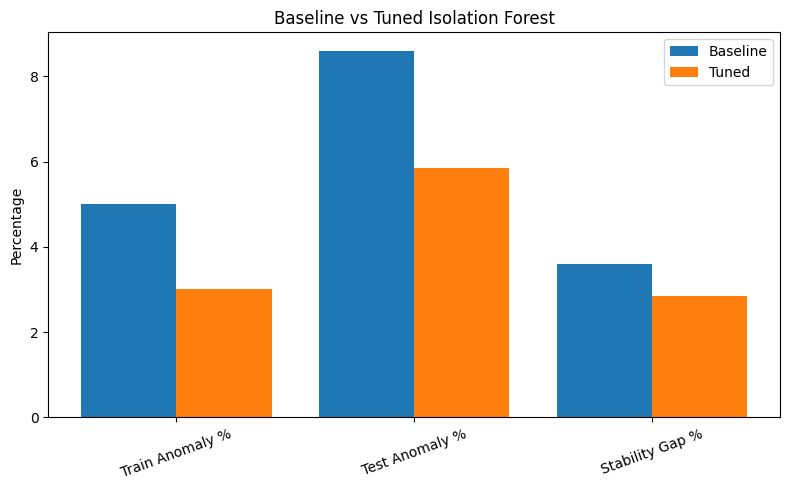

In [54]:
import matplotlib.pyplot as plt

metrics = ["Train Anomaly %", "Test Anomaly %", "Stability Gap %"]
baseline_vals = [5.00, 8.60, 3.60]
tuned_vals = [3.00, 5.84, 2.84]

x = range(len(metrics))

plt.figure(figsize=(8,5))
plt.bar(x, baseline_vals, width=0.4, label="Baseline", align='center')
plt.bar([i+0.4 for i in x], tuned_vals, width=0.4, label="Tuned", align='center')

plt.xticks([i+0.2 for i in x], metrics, rotation=20)
plt.ylabel("Percentage")
plt.title("Baseline vs Tuned Isolation Forest")
plt.legend()
plt.tight_layout()
plt.show()

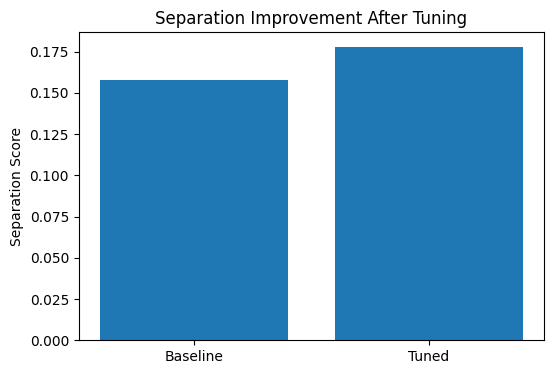

In [55]:
plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Tuned"], [0.1576, 0.1778])
plt.ylabel("Separation Score")
plt.title("Separation Improvement After Tuning")
plt.show()

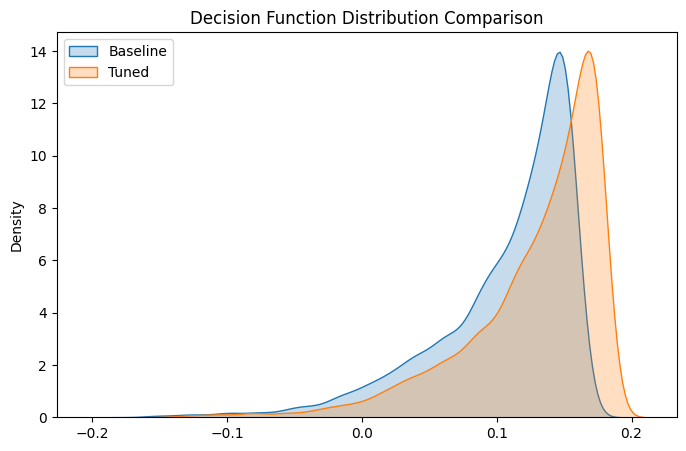

In [56]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(baseline_train_scores, label="Baseline", fill=True)
sns.kdeplot(train_scores, label="Tuned", fill=True)

plt.title("Decision Function Distribution Comparison")
plt.legend()
plt.show()

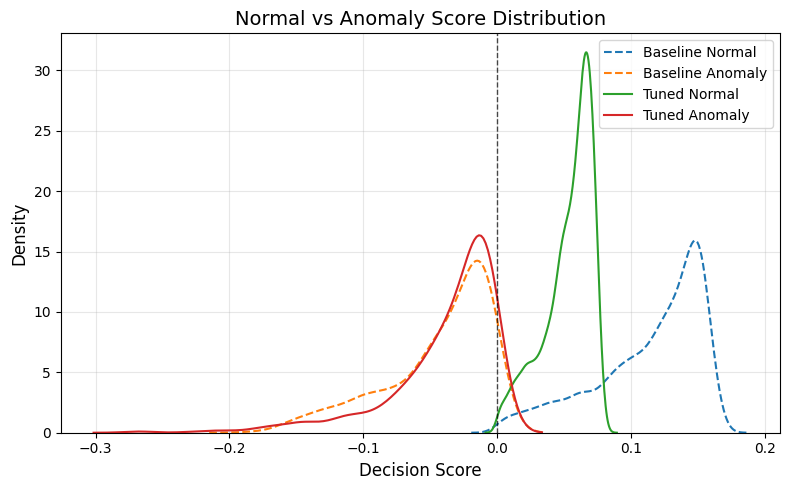

In [57]:
plt.figure(figsize=(8,5))

sns.kdeplot(baseline_normal_scores, label="Baseline Normal", linestyle="--")
sns.kdeplot(baseline_anomaly_scores, label="Baseline Anomaly", linestyle="--")

sns.kdeplot(normal_scores, label="Tuned Normal")
sns.kdeplot(anomaly_scores, label="Tuned Anomaly")

plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

plt.title("Normal vs Anomaly Score Distribution", fontsize=14)
plt.xlabel("Decision Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **LSTM**

In [81]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [82]:

data_path = "nasa_power_daily_raw.csv"

df = pd.read_csv(data_path)

print(df.shape)
print(df.head())

(12785, 10)
     city  latitude  longitude        date   T2M  T2M_MAX  T2M_MIN  \
0  London   51.5074    -0.1278  2016-01-01  5.17     7.09     2.47   
1  London   51.5074    -0.1278  2016-01-02  8.58     9.52     6.72   
2  London   51.5074    -0.1278  2016-01-03  6.55     8.29     4.25   
3  London   51.5074    -0.1278  2016-01-04  7.05     8.49     5.85   
4  London   51.5074    -0.1278  2016-01-05  7.32     9.28     5.91   

   PRECTOTCORR   RH2M  WS2M  
0         5.18  94.66  3.94  
1         3.50  95.32  5.20  
2        11.59  96.01  4.50  
3         6.88  95.86  3.68  
4         3.12  96.07  2.04  


In [83]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date']).reset_index(drop=True)

In [84]:
print("Total null values per column:")
print(df.isnull().sum())

print("\nTotal rows:", len(df))

Total null values per column:
city           0
latitude       0
longitude      0
date           0
T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
dtype: int64

Total rows: 12785


In [85]:
df = df.groupby('city').apply(lambda x: x.ffill()).reset_index(drop=True)
df = df.groupby('city').apply(lambda x: x.bfill()).reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

print("After null handling:", df.shape)

After null handling: (12785, 10)


/tmp/ipykernel_14548/3845622878.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('city').apply(lambda x: x.ffill()).reset_index(drop=True)
/tmp/ipykernel_14548/3845622878.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('city').apply(lambda x: x.bfill()).reset_index(drop=True)


Feature engineering

In [86]:
df_numeric = df.select_dtypes(include=[np.number]).copy()

In [87]:
rolling_window = 7

for col in df_numeric.columns:
    df_numeric[f"{col}_roll_mean"] = df_numeric[col].rolling(rolling_window).mean()
    df_numeric[f"{col}_roll_std"] = df_numeric[col].rolling(rolling_window).std()

df_numeric = df_numeric.dropna().reset_index(drop=True)

In [88]:
X = df_numeric.values

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
X_test  = X[split_index:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (10223, 24)
Test: (2556, 24)


SCALING (FIT ON TRAIN ONLY)

In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [90]:
WINDOW_SIZE = 60

def create_sequences(data, window):
    sequences = []
    for i in range(len(data) - window):
        sequences.append(data[i:i+window])
    return np.array(sequences)

X_train_seq = create_sequences(X_train_scaled, WINDOW_SIZE)
X_test_seq  = create_sequences(X_test_scaled, WINDOW_SIZE)

print("Train seq:", X_train_seq.shape)
print("Test seq:", X_test_seq.shape)

Train seq: (10163, 60, 24)
Test seq: (2496, 60, 24)


CONVERT TO TENSORS

In [91]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

LSTM Autoencoder

In [99]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64, latent_dim=32):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc_enc = nn.Linear(hidden_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=n_features,
            batch_first=True
        )

    def forward(self, x):
        encoded_seq, _ = self.encoder(x)
        last_hidden = encoded_seq[:, -1, :]

        latent = torch.relu(self.fc_enc(last_hidden))
        decoded_input = torch.relu(self.fc_dec(latent)).unsqueeze(1)
        decoded_input = decoded_input.repeat(1, x.size(1), 1)

        reconstructed, _ = self.decoder(decoded_input)
        return reconstructed

#Initialise model
n_features = X_train_seq.shape[2]

model = LSTMAutoencoder(n_features).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#Train Model
baseline_epoch_losses = []
baseline_train_start = time.time()

EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    baseline_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_epoch_loss:.6f}")

baseline_train_end = time.time()
baseline_train_time_lstm = round(baseline_train_end - baseline_train_start, 4)

Epoch 1/30, Loss: 0.715065
Epoch 2/30, Loss: 0.578345
Epoch 3/30, Loss: 0.562009
Epoch 4/30, Loss: 0.551451
Epoch 5/30, Loss: 0.543434
Epoch 6/30, Loss: 0.537738
Epoch 7/30, Loss: 0.530985
Epoch 8/30, Loss: 0.527315
Epoch 9/30, Loss: 0.523594
Epoch 10/30, Loss: 0.521492
Epoch 11/30, Loss: 0.518400
Epoch 12/30, Loss: 0.516749
Epoch 13/30, Loss: 0.515051
Epoch 14/30, Loss: 0.513544
Epoch 15/30, Loss: 0.511374
Epoch 16/30, Loss: 0.511247
Epoch 17/30, Loss: 0.507643
Epoch 18/30, Loss: 0.507056
Epoch 19/30, Loss: 0.504742
Epoch 20/30, Loss: 0.502897
Epoch 21/30, Loss: 0.501609
Epoch 22/30, Loss: 0.500112
Epoch 23/30, Loss: 0.497779
Epoch 24/30, Loss: 0.501892
Epoch 25/30, Loss: 0.495617
Epoch 26/30, Loss: 0.493851
Epoch 27/30, Loss: 0.493325
Epoch 28/30, Loss: 0.495173
Epoch 29/30, Loss: 0.491476
Epoch 30/30, Loss: 0.489913


In [114]:
print(baseline_train_time_lstm )

93.675


RECONSTRUCTION ERROR

In [107]:
model.eval()

with torch.no_grad():
    train_recon = model(X_train_tensor).cpu().numpy()
    test_recon  = model(X_test_tensor).cpu().numpy()

train_loss = np.mean((X_train_seq - train_recon)**2, axis=(1,2))
test_loss  = np.mean((X_test_seq - test_recon)**2, axis=(1,2))

THRESHOLD (Statistical)

In [108]:
threshold = train_loss.mean() + 3 * train_loss.std()

train_preds = (train_loss > threshold).astype(int)
test_preds  = (test_loss > threshold).astype(int)

print("Train anomaly %:", round(train_preds.mean()*100,2))
print("Test anomaly %:", round(test_preds.mean()*100,2))

Train anomaly %: 1.21
Test anomaly %: 0.16


**Metrics**

In [109]:
stability_gap = abs(train_preds.mean() - test_preds.mean())
print("Stability Gap:", round(stability_gap*100,2), "%")

Stability Gap: 1.05 %


In [110]:
normal_scores = train_loss[train_preds == 0]
anomaly_scores = train_loss[train_preds == 1]

separation_score = anomaly_scores.mean() - normal_scores.mean()
print("Separation Score:", round(separation_score,4))

Separation Score: 5.4123


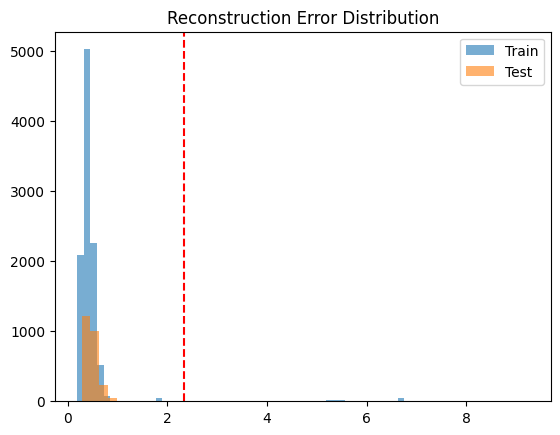

In [111]:
plt.hist(train_loss, bins=50, alpha=0.6, label="Train")
plt.hist(test_loss, bins=50, alpha=0.6, label="Test")
plt.axvline(threshold, color='red', linestyle='--')
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

In [112]:
print("\nModel Evaluation")
print("Train anomaly %:", round(train_preds.mean()*100,2))
print("Test anomaly %:", round(test_preds.mean()*100,2))
print("Stability Gap %:", round(stability_gap*100,2))
print("Separation Score:", round(separation_score,4))


Model Evaluation
Train anomaly %: 1.21
Test anomaly %: 0.16
Stability Gap %: 1.05
Separation Score: 5.4123


In [113]:
baseline_train_loss_lstm = train_loss.copy()
baseline_test_loss_lstm = test_loss.copy()
baseline_threshold_lstm = threshold
baseline_train_anom_lstm = round(train_preds.mean() * 100, 4)
baseline_test_anom_lstm = round(test_preds.mean() * 100, 4)
baseline_gap_lstm = round(stability_gap * 100, 4)
baseline_sep_lstm = round(separation_score, 4)

LSTM HYPERPARAMETER TUNING

In [115]:
# LSTM HYPERPARAMETER TUNING


import time
import copy
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)


if "baseline_train_loss_lstm" not in globals():
    print("Reconstructing baseline LSTM metrics from current baseline model...")


    model.eval()
    with torch.no_grad():
        baseline_train_recon = model(X_train_tensor).cpu().numpy()
        baseline_test_recon  = model(X_test_tensor).cpu().numpy()

    baseline_train_loss_lstm = np.mean((X_train_seq - baseline_train_recon) ** 2, axis=(1, 2))
    baseline_test_loss_lstm  = np.mean((X_test_seq  - baseline_test_recon) ** 2, axis=(1, 2))

    baseline_threshold_lstm = baseline_train_loss_lstm.mean() + 3 * baseline_train_loss_lstm.std()

    baseline_train_preds_lstm = (baseline_train_loss_lstm > baseline_threshold_lstm).astype(int)
    baseline_test_preds_lstm  = (baseline_test_loss_lstm  > baseline_threshold_lstm).astype(int)

    baseline_train_anom_lstm = baseline_train_preds_lstm.mean() * 100
    baseline_test_anom_lstm  = baseline_test_preds_lstm.mean() * 100
    baseline_gap_lstm        = abs(
        baseline_train_preds_lstm.mean() - baseline_test_preds_lstm.mean()
    ) * 100

    baseline_normal_scores_lstm  = baseline_train_loss_lstm[baseline_train_preds_lstm == 0]
    baseline_anomaly_scores_lstm = baseline_train_loss_lstm[baseline_train_preds_lstm == 1]
    baseline_sep_lstm = baseline_anomaly_scores_lstm.mean() - baseline_normal_scores_lstm.mean()

if "baseline_train_time_lstm" not in globals():
    baseline_train_time_lstm = np.nan

if "baseline_epoch_losses" not in globals():
    baseline_epoch_losses = []

print("Baseline LSTM metrics ready.")


# Validation split for LSTM tuning

val_ratio = 0.15
n_train_seq = len(X_train_seq)
val_size = int(n_train_seq * val_ratio)
train_size = n_train_seq - val_size

X_train_seq_sub = X_train_seq[:train_size]
X_val_seq = X_train_seq[train_size:]

X_train_sub_tensor = torch.tensor(X_train_seq_sub, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)

train_dataset_tune = TensorDataset(X_train_sub_tensor, X_train_sub_tensor)
val_dataset_tune   = TensorDataset(X_val_tensor, X_val_tensor)

print("Tuning train sequences:", X_train_sub_tensor.shape)
print("Validation sequences:", X_val_tensor.shape)

# Tuned LSTM Autoencoder
class TunedLSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=128, latent_dim=64, num_layers=2, dropout=0.2):
        super().__init__()

        enc_dropout = dropout if num_layers > 1 else 0.0
        dec_dropout = dropout if num_layers > 1 else 0.0

        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=enc_dropout,
            batch_first=True
        )

        self.fc_enc = nn.Linear(hidden_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, hidden_size)

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dec_dropout,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        encoded_seq, _ = self.encoder(x)
        last_hidden = encoded_seq[:, -1, :]
        latent = torch.relu(self.fc_enc(last_hidden))

        repeated = torch.relu(self.fc_dec(latent)).unsqueeze(1).repeat(1, x.size(1), 1)
        decoded_seq, _ = self.decoder(repeated)
        reconstructed = self.output_layer(decoded_seq)
        return reconstructed


# Training / evaluation helpers

def train_autoencoder_model(
    model,
    train_loader,
    val_loader,
    lr=0.001,
    epochs=40,
    weight_decay=1e-5,
    patience=8
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": []
    }

    best_model_state = None
    best_val_loss = float("inf")
    patience_counter = 0

    train_start = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)

            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_x)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_train_loss += loss.item()

        epoch_train_loss /= len(train_loader)

        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_x, _ in val_loader:
                batch_x = batch_x.to(device)
                output = model(batch_x)
                loss = criterion(output, batch_x)
                epoch_val_loss += loss.item()

        epoch_val_loss /= len(val_loader)
        scheduler.step(epoch_val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {epoch_train_loss:.6f} | "
            f"Val Loss: {epoch_val_loss:.6f} | "
            f"LR: {current_lr:.6f}"
        )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

    train_end = time.time()
    training_time = round(train_end - train_start, 4)

    model.load_state_dict(best_model_state)

    return model, history, best_val_loss, training_time


def get_reconstruction_errors(model, data_tensor, data_seq):
    model.eval()
    start_pred = time.time()
    with torch.no_grad():
        recon = model(data_tensor.to(device)).cpu().numpy()
    end_pred = time.time()

    reconstruction_error = np.mean((data_seq - recon) ** 2, axis=(1, 2))
    prediction_time = round(end_pred - start_pred, 4)
    return reconstruction_error, prediction_time


def compute_lstm_metrics(train_loss, test_loss, threshold):
    train_preds = (train_loss > threshold).astype(int)
    test_preds  = (test_loss > threshold).astype(int)

    train_anom_pct = train_preds.mean() * 100
    test_anom_pct  = test_preds.mean() * 100
    stability_gap  = abs(train_preds.mean() - test_preds.mean()) * 100

    normal_scores = train_loss[train_preds == 0]
    anomaly_scores = train_loss[train_preds == 1]

    if len(normal_scores) > 0 and len(anomaly_scores) > 0:
        separation_score = anomaly_scores.mean() - normal_scores.mean()
    else:
        separation_score = np.nan

    return {
        "train_preds": train_preds,
        "test_preds": test_preds,
        "train_anom_pct": round(train_anom_pct, 4),
        "test_anom_pct": round(test_anom_pct, 4),
        "stability_gap_pct": round(stability_gap, 4),
        "separation_score": round(separation_score, 4),
        "normal_scores": normal_scores,
        "anomaly_scores": anomaly_scores
    }


def score_lstm_candidate(metrics_dict):

    sep = metrics_dict["separation_score"]
    gap = metrics_dict["stability_gap_pct"]
    test_anom = metrics_dict["test_anom_pct"]

    if np.isnan(sep):
        return -np.inf

    score = sep - (0.25 * gap)

    #avoid models that collapse to almost zero anomalies
    if test_anom < 0.20:
        score -= 0.50

    return score


# Hyperparameter grid

param_grid = [
    {"hidden_size": 64,  "latent_dim": 32, "num_layers": 1, "dropout": 0.0, "batch_size": 64, "lr": 0.001,  "epochs": 35},
    {"hidden_size": 128, "latent_dim": 32, "num_layers": 1, "dropout": 0.0, "batch_size": 64, "lr": 0.001,  "epochs": 40},
    {"hidden_size": 128, "latent_dim": 64, "num_layers": 2, "dropout": 0.2, "batch_size": 64, "lr": 0.001,  "epochs": 40},
    {"hidden_size": 128, "latent_dim": 64, "num_layers": 2, "dropout": 0.3, "batch_size": 128, "lr": 0.0005, "epochs": 45},
    {"hidden_size": 256, "latent_dim": 64, "num_layers": 2, "dropout": 0.2, "batch_size": 64, "lr": 0.0005, "epochs": 45},
]


# Run tuning

tuning_results = []
best_tuned_model = None
best_tuned_history = None
best_tuned_params = None
best_tuned_metrics = None
best_tuned_threshold = None
best_tuned_train_loss = None
best_tuned_test_loss = None
best_tuned_train_time = None
best_tuned_pred_time = None
best_tuning_score = -np.inf

for idx, params in enumerate(param_grid, start=1):
    print("\n" + "=" * 80)
    print(f"Tuning Trial {idx}/{len(param_grid)}")
    print("Parameters:", params)

    batch_size = params["batch_size"]
    lr = params["lr"]
    epochs = params["epochs"]

    train_loader_tune = DataLoader(train_dataset_tune, batch_size=batch_size, shuffle=True)
    val_loader_tune   = DataLoader(val_dataset_tune, batch_size=batch_size, shuffle=False)

    candidate_model = TunedLSTMAutoencoder(
        n_features=X_train_seq.shape[2],
        hidden_size=params["hidden_size"],
        latent_dim=params["latent_dim"],
        num_layers=params["num_layers"],
        dropout=params["dropout"]
    ).to(device)

    candidate_model, candidate_history, best_val_loss, candidate_train_time = train_autoencoder_model(
        model=candidate_model,
        train_loader=train_loader_tune,
        val_loader=val_loader_tune,
        lr=lr,
        epochs=epochs,
        weight_decay=1e-5,
        patience=8
    )

    # Evaluate on full train/test sequence sets
    full_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
    full_test_tensor  = torch.tensor(X_test_seq, dtype=torch.float32)

    candidate_train_loss, candidate_pred_time_train = get_reconstruction_errors(
        candidate_model, full_train_tensor, X_train_seq
    )
    candidate_test_loss, candidate_pred_time_test = get_reconstruction_errors(
        candidate_model, full_test_tensor, X_test_seq
    )

    candidate_pred_time = round(candidate_pred_time_train + candidate_pred_time_test, 4)

    # Threshold from train distribution
    candidate_threshold = np.percentile(candidate_train_loss, 97)

    candidate_metrics = compute_lstm_metrics(
        train_loss=candidate_train_loss,
        test_loss=candidate_test_loss,
        threshold=candidate_threshold
    )

    candidate_score = score_lstm_candidate(candidate_metrics)

    trial_result = {
        "trial": idx,
        "hidden_size": params["hidden_size"],
        "latent_dim": params["latent_dim"],
        "num_layers": params["num_layers"],
        "dropout": params["dropout"],
        "batch_size": batch_size,
        "lr": lr,
        "epochs": epochs,
        "best_val_loss": round(best_val_loss, 6),
        "train_anomaly_pct": candidate_metrics["train_anom_pct"],
        "test_anomaly_pct": candidate_metrics["test_anom_pct"],
        "stability_gap_pct": candidate_metrics["stability_gap_pct"],
        "separation_score": candidate_metrics["separation_score"],
        "training_time_sec": candidate_train_time,
        "prediction_time_sec": candidate_pred_time,
        "selection_score": round(candidate_score, 4)
    }
    tuning_results.append(trial_result)

    print("Trial Metrics:")
    print(pd.Series(trial_result))

    if candidate_score > best_tuning_score:
        best_tuning_score = candidate_score
        best_tuned_model = copy.deepcopy(candidate_model)
        best_tuned_history = copy.deepcopy(candidate_history)
        best_tuned_params = params
        best_tuned_metrics = candidate_metrics
        best_tuned_threshold = candidate_threshold
        best_tuned_train_loss = candidate_train_loss
        best_tuned_test_loss = candidate_test_loss
        best_tuned_train_time = candidate_train_time
        best_tuned_pred_time = candidate_pred_time

print("\nBest Tuned LSTM Parameters:")
print(best_tuned_params)

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by=["selection_score", "separation_score"], ascending=False
).reset_index(drop=True)

print("\nTuning Summary:")
print(tuning_results_df)



Device: cuda
Baseline LSTM metrics ready.
Tuning train sequences: torch.Size([8639, 60, 24])
Validation sequences: torch.Size([1524, 60, 24])

Tuning Trial 1/5
Parameters: {'hidden_size': 64, 'latent_dim': 32, 'num_layers': 1, 'dropout': 0.0, 'batch_size': 64, 'lr': 0.001, 'epochs': 35}
Epoch 01/35 | Train Loss: 0.714032 | Val Loss: 0.663566 | LR: 0.001000
Epoch 02/35 | Train Loss: 0.566758 | Val Loss: 0.552063 | LR: 0.001000
Epoch 03/35 | Train Loss: 0.537953 | Val Loss: 0.529704 | LR: 0.001000
Epoch 04/35 | Train Loss: 0.521927 | Val Loss: 0.524396 | LR: 0.001000
Epoch 05/35 | Train Loss: 0.511132 | Val Loss: 0.517823 | LR: 0.001000
Epoch 06/35 | Train Loss: 0.503189 | Val Loss: 0.517688 | LR: 0.001000
Epoch 07/35 | Train Loss: 0.494517 | Val Loss: 0.522577 | LR: 0.001000
Epoch 08/35 | Train Loss: 0.485937 | Val Loss: 0.517649 | LR: 0.001000
Epoch 09/35 | Train Loss: 0.476091 | Val Loss: 0.516547 | LR: 0.001000
Epoch 10/35 | Train Loss: 0.462298 | Val Loss: 0.511039 | LR: 0.001000
Ep

In [120]:
import pandas as pd
import numpy as np

# Baseline vs Tuned LSTM Results Table

lstm_results = pd.DataFrame({
    "Metric": [
        "Train Anomaly %",
        "Test Anomaly %",
        "Stability Gap %",
        "Separation Score",
        "Training Time (sec)",

    ],
    "Baseline LSTM": [
        round(baseline_train_anom_lstm, 4),
        round(baseline_test_anom_lstm, 4),
        round(baseline_gap_lstm, 4),
        round(baseline_sep_lstm, 4),
        round(baseline_train_time_lstm, 4) if not pd.isna(baseline_train_time_lstm) else np.nan
    ],
    "Tuned LSTM": [
        round(best_tuned_metrics["train_anom_pct"], 4),
        round(best_tuned_metrics["test_anom_pct"], 4),
        round(best_tuned_metrics["stability_gap_pct"], 4),
        round(best_tuned_metrics["separation_score"], 4),
        round(best_tuned_train_time, 4)


    ]
})

lstm_results["Improvement"] = lstm_results["Tuned LSTM"] - lstm_results["Baseline LSTM"]
print("\nBaseline vs Tuned LSTM Results:")
print(lstm_results)


Baseline vs Tuned LSTM Results:
                Metric  Baseline LSTM  Tuned LSTM  Improvement
0      Train Anomaly %         1.2103      3.0011       1.7908
1       Test Anomaly %         0.1603      2.7244       2.5641
2      Stability Gap %         1.0500      0.2767      -0.7733
3     Separation Score         5.4123      2.3754      -3.0369
4  Training Time (sec)        93.6750      9.6164     -84.0586


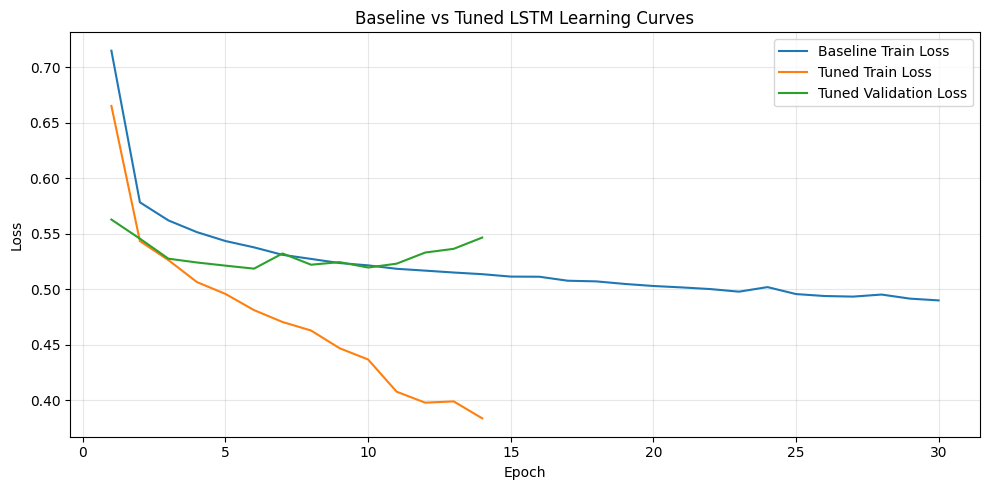

In [121]:
plt.figure(figsize=(10, 5))
if len(baseline_epoch_losses) > 0:
    plt.plot(range(1, len(baseline_epoch_losses) + 1), baseline_epoch_losses, label="Baseline Train Loss")
plt.plot(range(1, len(best_tuned_history["train_loss"]) + 1), best_tuned_history["train_loss"], label="Tuned Train Loss")
plt.plot(range(1, len(best_tuned_history["val_loss"]) + 1), best_tuned_history["val_loss"], label="Tuned Validation Loss")
plt.title("Baseline vs Tuned LSTM Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


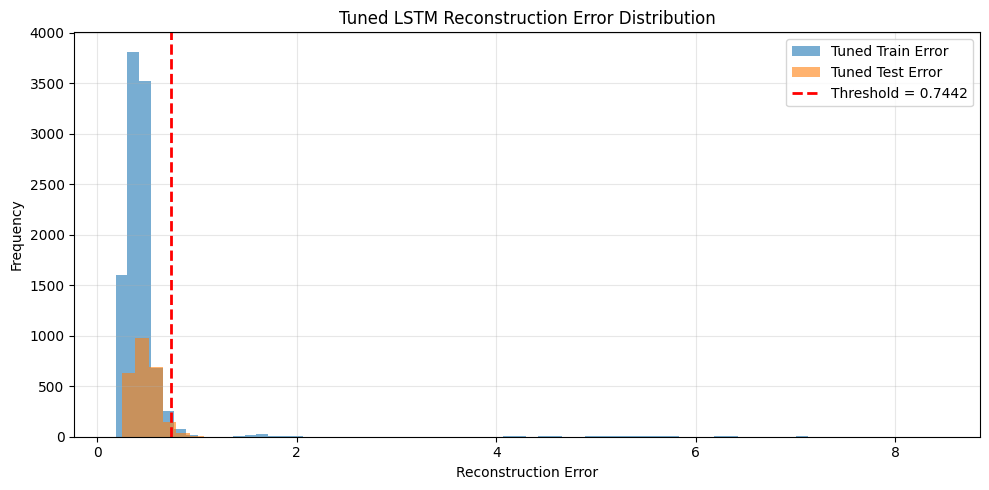

In [122]:
plt.figure(figsize=(10, 5))
plt.hist(best_tuned_train_loss, bins=60, alpha=0.6, label="Tuned Train Error")
plt.hist(best_tuned_test_loss, bins=60, alpha=0.6, label="Tuned Test Error")
plt.axvline(best_tuned_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold = {best_tuned_threshold:.4f}")
plt.title("Tuned LSTM Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


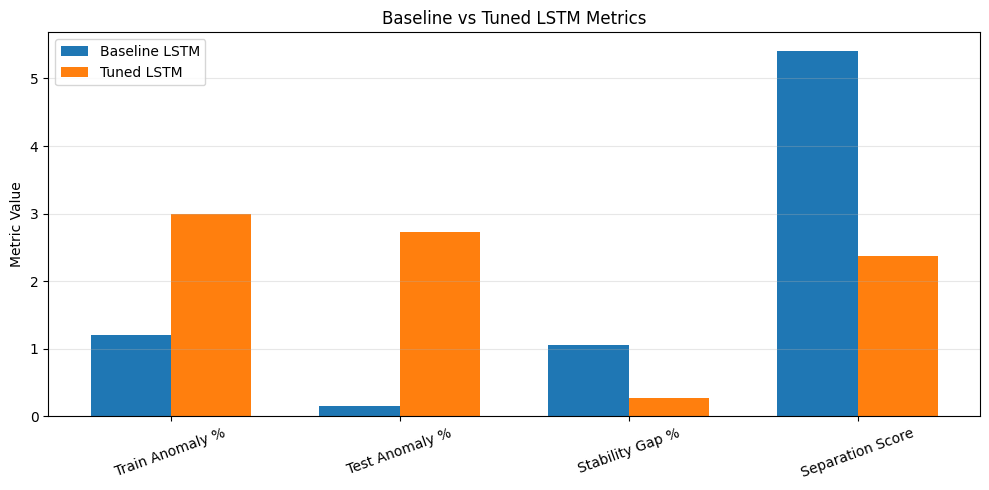

In [123]:
lstm_plot_df = lstm_results[lstm_results["Metric"].isin([
    "Train Anomaly %",
    "Test Anomaly %",
    "Stability Gap %",
    "Separation Score"
])].copy()

x = np.arange(len(lstm_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, lstm_plot_df["Baseline LSTM"], width, label="Baseline LSTM")
plt.bar(x + width/2, lstm_plot_df["Tuned LSTM"], width, label="Tuned LSTM")
plt.xticks(x, lstm_plot_df["Metric"], rotation=20)
plt.title("Baseline vs Tuned LSTM Metrics")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [126]:

# FINAL CROSS-MODEL COMPARISON


all_models_results = pd.DataFrame({
    "Model": [
        "Baseline IF",
        "Tuned IF",
        "Baseline LSTM",
        "Tuned LSTM"
    ],
    "Train Anomaly %": [
        round(baseline_train_anom, 4),
        round(tuned_train_anom, 4),
        round(baseline_train_anom_lstm, 4),
        round(best_tuned_metrics["train_anom_pct"], 4)
    ],
    "Test Anomaly %": [
        round(baseline_test_anom, 4),
        round(tuned_test_anom, 4),
        round(baseline_test_anom_lstm, 4),
        round(best_tuned_metrics["test_anom_pct"], 4)
    ],
    "Stability Gap %": [
        round(baseline_gap, 4),
        round(tuned_gap, 4),
        round(baseline_gap_lstm, 4),
        round(best_tuned_metrics["stability_gap_pct"], 4)
    ],
    "Separation Score": [
        round(baseline_sep, 4),
        round(tuned_sep, 4),
        round(baseline_sep_lstm, 4),
        round(best_tuned_metrics["separation_score"], 4)
    ],
    "Training Time (sec)": [
        round(baseline_time, 4) if "baseline_time" in globals() else np.nan,
        round(tuned_time, 4) if "tuned_time" in globals() else np.nan,
        round(baseline_train_time_lstm, 4) if "baseline_train_time_lstm" in globals() else np.nan,
        round(best_tuned_train_time, 4) if "best_tuned_train_time" in globals() else np.nan
    ]
})


def final_model_score(row):
    score = 0.0

    # Main performance
    score += 0.8 * row["Separation Score"]
    score -= 0.8 * row["Stability Gap %"]

    # Reward reasonable anomaly detection on unseen data
    if 1.0 <= row["Test Anomaly %"] <= 6.0:
        score += 2.0
    elif 0.5 <= row["Test Anomaly %"] < 1.0:
        score += 0.5
    elif row["Test Anomaly %"] < 0.5:
        score -= 3.0
    elif row["Test Anomaly %"] > 10.0:
        score -= 1.0

    if not pd.isna(row["Training Time (sec)"]):
        score -= 0.01 * row["Training Time (sec)"]

    return round(score, 4)

all_models_results["Final Score"] = all_models_results.apply(final_model_score, axis=1)

all_models_results = all_models_results.sort_values(
    by=["Final Score", "Stability Gap %", "Training Time (sec)"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\nAll Models Comparison:")
print(all_models_results)

best_model_name = all_models_results.iloc[0]["Model"]
print("\nSelected Best Model:", best_model_name)


All Models Comparison:
           Model  Train Anomaly %  Test Anomaly %  Stability Gap %  \
0     Tuned LSTM           3.0011          2.7244           0.2767   
1       Tuned IF           3.0022          5.8380           2.8358   
2  Baseline LSTM           1.2103          0.1603           1.0500   
3    Baseline IF           5.0000          8.6034           3.6034   

   Separation Score  Training Time (sec)  Final Score  
0            2.3754               9.6164       3.5828  
1            0.1778                  NaN      -0.1264  
2            5.4123              93.6750      -0.4469  
3            0.1576               0.4498      -2.7611  

Selected Best Model: Tuned LSTM


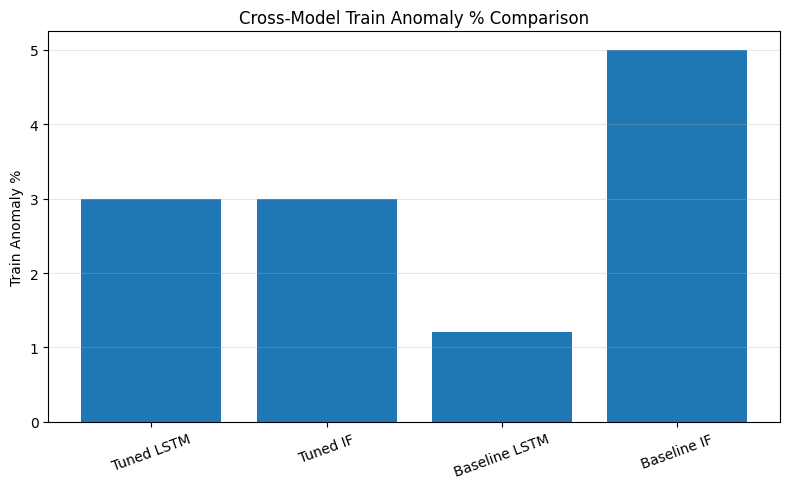

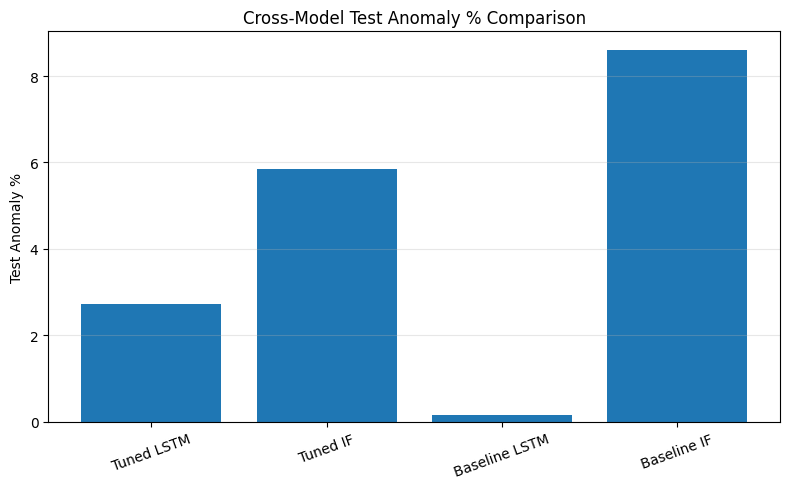

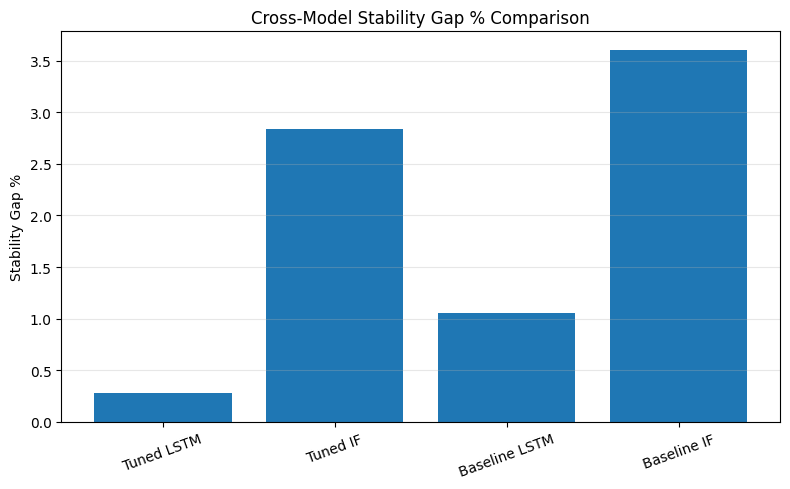

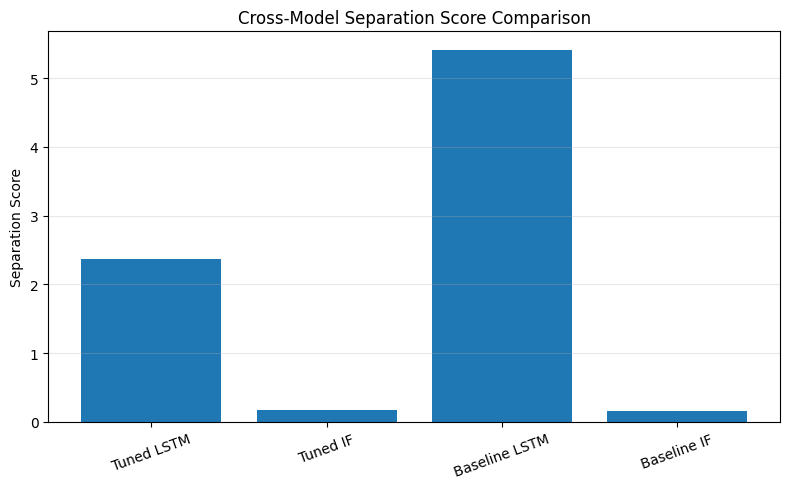

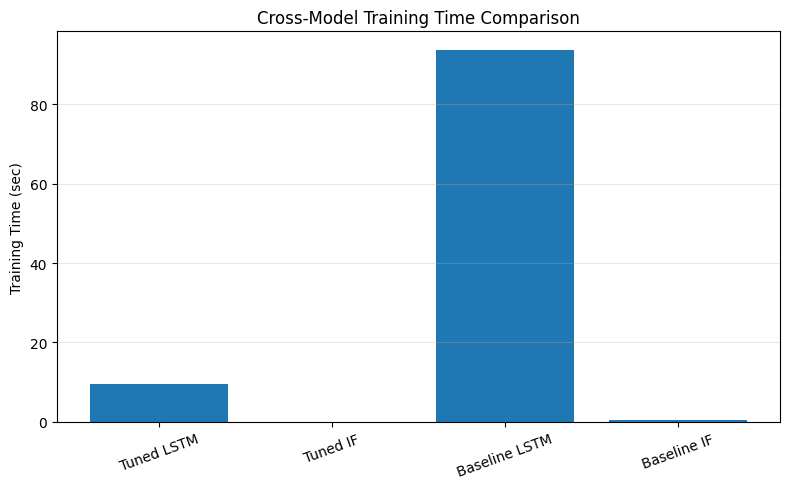

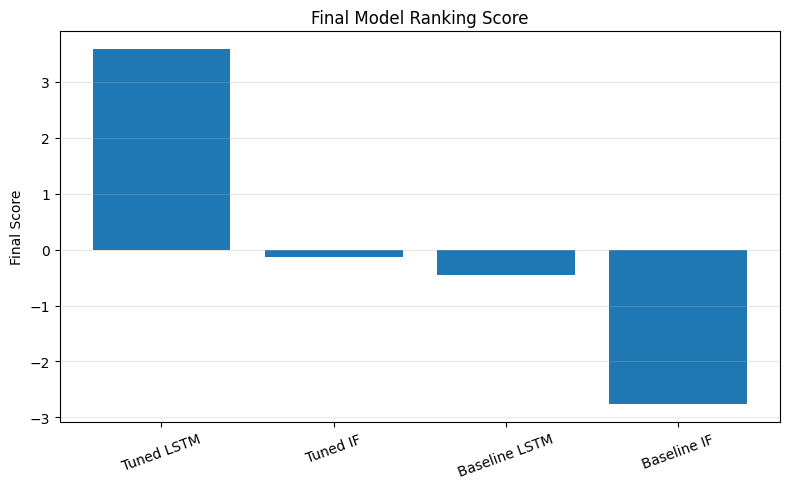

In [133]:

# CROSS-MODEL VISUALISATIONS


# 1. Train anomaly %
plt.figure(figsize=(8, 5))
plt.bar(all_models_results["Model"], all_models_results["Train Anomaly %"])
plt.title("Cross-Model Train Anomaly % Comparison")
plt.ylabel("Train Anomaly %")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Test anomaly %
plt.figure(figsize=(8, 5))
plt.bar(all_models_results["Model"], all_models_results["Test Anomaly %"])
plt.title("Cross-Model Test Anomaly % Comparison")
plt.ylabel("Test Anomaly %")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Stability gap %
plt.figure(figsize=(8, 5))
plt.bar(all_models_results["Model"], all_models_results["Stability Gap %"])
plt.title("Cross-Model Stability Gap % Comparison")
plt.ylabel("Stability Gap %")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Separation score
plt.figure(figsize=(8, 5))
plt.bar(all_models_results["Model"], all_models_results["Separation Score"])
plt.title("Cross-Model Separation Score Comparison")
plt.ylabel("Separation Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Training time
plt.figure(figsize=(8, 5))
plt.bar(all_models_results["Model"], all_models_results["Training Time (sec)"])
plt.title("Cross-Model Training Time Comparison")
plt.ylabel("Training Time (sec)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Final score
plt.figure(figsize=(8, 5))
plt.bar(all_models_results["Model"], all_models_results["Final Score"])
plt.title("Final Model Ranking Score")
plt.ylabel("Final Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()